# Análisis Exploratorio de Datos y Limpieza - Bike Sharing

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## Carga del dataset

In [2]:
BASE_DIR = Path().resolve().parent 

data_path = BASE_DIR / "data" / "bike_sharing_hour.csv"

df = pd.read_csv(data_path)

## Exploración inicial

In [3]:
df.shape

(17379, 17)

Este dataset contiene **17.379 registros y 17 variables**.

Cada fila representa una observación horaria del sistema de alquiler de bicicletas.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


Observaciones importantes:

- No hay valores nulos en ninguna columna → dataset completo
- Existen variables numéricas (int y float) y una variable tipo texto (`dteday`)
- La mayoría de variables son numéricas codificadas (ej: season, weekday, weathersit)
- El dataset está listo para análisis sin limpieza inicial de nulos

In [5]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


El análisis de los estadísticos descriptivos permite extraer varias conclusiones relevantes:

- La variable objetivo (`cnt`) presenta una media de ~189 alquileres por hora y una desviación estándar elevada (~181), lo que indica una alta variabilidad en la demanda.

- Las variables relacionadas con el uso (`casual` y `registered`) muestran diferencias importantes en su escala, siendo los usuarios registrados los que concentran la mayor parte de los alquileres.

- Las variables meteorológicas (`temp`, `atemp`, `hum`, `windspeed`) están normalizadas en rangos entre 0 y 1, lo que indica que han sido previamente escaladas.

- No se observan valores negativos ni inconsistencias evidentes en ninguna variable.

- Variables como `hr`, `mnth` y `weekday` cubren correctamente sus rangos esperados, lo que confirma la integridad temporal del dataset.

## Calidad de datos

In [6]:
# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [7]:
# Duplicados
print("\nFilas duplicadas:", df.duplicated().sum())


Filas duplicadas: 0


## Preprocesamiento inicial

In [8]:
# Eliminación de variables irrelevantes o que provocan data leakage
df = df.drop(columns=["instant", "casual", "registered", "dteday"])

df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


Se eliminan las siguientes columnas:

- **instant**: identificador del registro, no aporta información predictiva
- **casual** y **registered**: generan data leakage, ya que su suma forma la variable objetivo (`cnt`)
- **dteday**: se sustituye por variables temporales derivadas (mes, hora, etc.)

Estas variables no aportan valor al modelo o pueden sesgar el entrenamiento, por lo que se eliminan antes del modelado.

# Análisis exploratorio de datos (EDA)

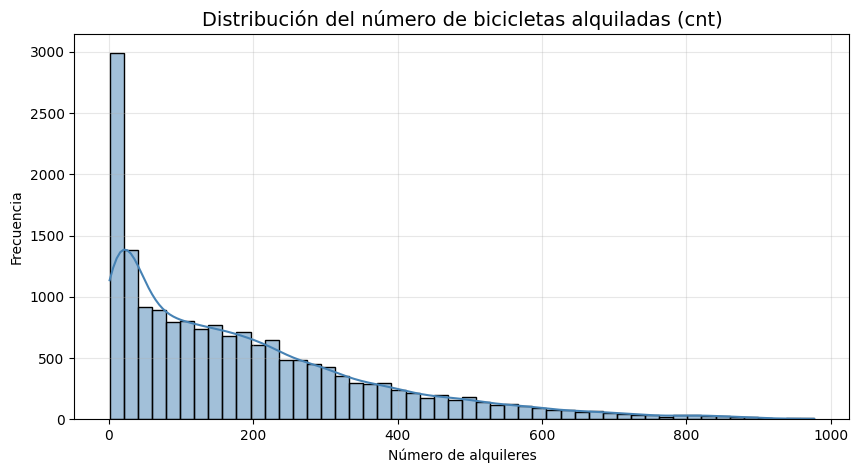

In [9]:
# Histograma de la variable objetivo (cnt) con KDE.
plt.figure(figsize=(10,5))

sns.histplot(df["cnt"], bins=50, kde=True, color="steelblue")

plt.title("Distribución del número de bicicletas alquiladas (cnt)", fontsize=14)
plt.xlabel("Número de alquileres")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)
plt.show()

La variable objetivo (`cnt`) presenta una distribución asimétrica hacia la derecha, con una alta concentración de valores bajos y una cola larga hacia valores altos.

Esto indica que la demanda de bicicletas es altamente variable, con la mayoría de las horas registrando pocos alquileres y algunas horas puntuales con picos de demanda muy elevados.

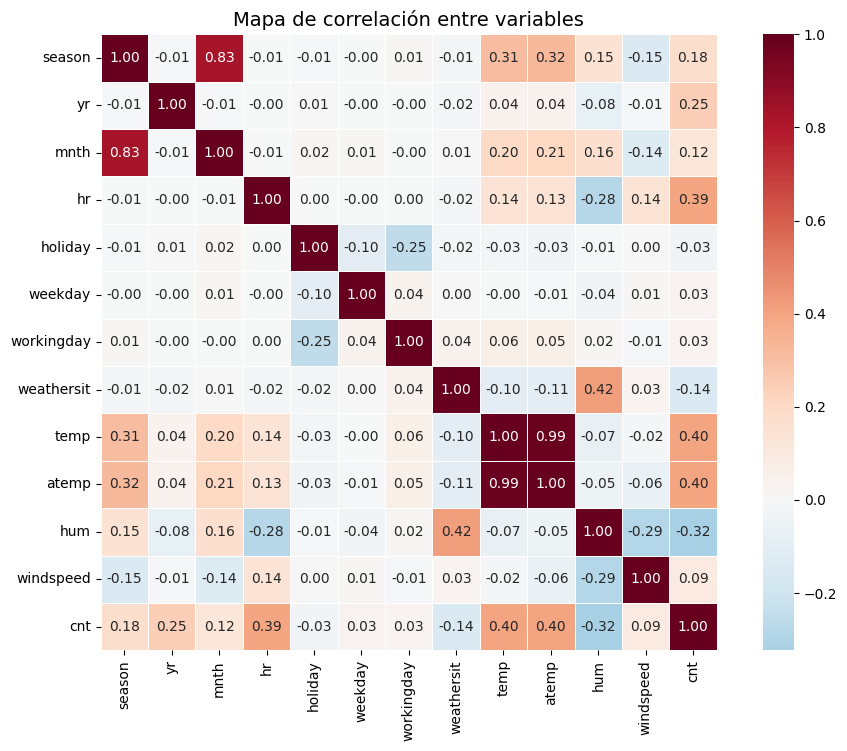

In [10]:
# Heatmap de correlación entre variables numéricas.
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Mapa de correlación entre variables", fontsize=14)
plt.show()

El mapa de correlación muestra relaciones interesantes entre variables. Destaca la fuerte correlación entre temp y atemp, lo que indica redundancia entre ambas. También se observa una relación positiva moderada entre la temperatura y el número de alquileres (cnt), mientras que la humedad presenta una correlación negativa con la demanda. El resto de variables muestran correlaciones débiles o poco relevantes con el objetivo.

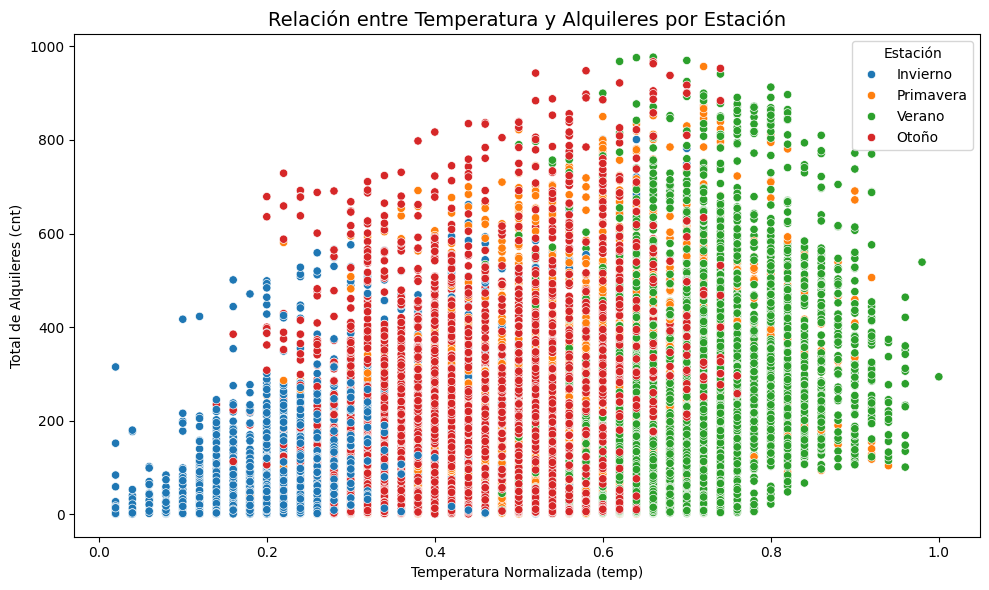

In [11]:
# Scatter plot: Relación entre temperatura y demanda, diferenciado por estación
df_viz = df.copy()
# Mapeo de estaciones según el diccionario de datos
season_labels = {1: 'Invierno', 2: 'Primavera', 3: 'Verano', 4: 'Otoño'}
df_viz['season_name'] = df_viz['season'].map(season_labels)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_viz, x='temp', y='cnt', hue='season_name')

plt.title("Relación entre Temperatura y Alquileres por Estación", fontsize=14)
plt.xlabel("Temperatura Normalizada (temp)")
plt.ylabel("Total de Alquileres (cnt)")
plt.legend(title="Estación")
plt.tight_layout()
plt.show()

El gráfico demuestra una clara relación positiva entre la temperatura y la demanda de bicicletas: a medida que aumenta la temperatura, el número de alquileres tiende a crecer. Se observa que el Verano y la Primavera se agrupan en los rangos de temperatura más altos con una mayor densidad de alquileres, mientras que el Invierno se concentra en temperaturas más bajas y niveles de uso reducidos, lo que confirma que la temperatura es un factor determinante en la actividad del sistema.

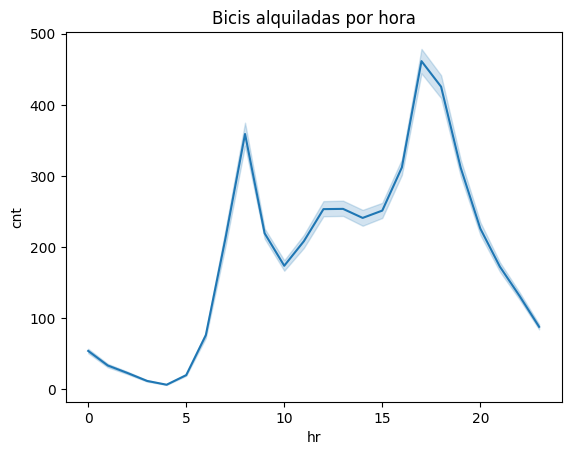

In [12]:
# Evolución del número de bicicletas alquiladas a lo largo del día.
sns.lineplot(data=df, x="hr", y="cnt")
plt.title("Bicis alquiladas por hora")
plt.show()

El gráfico muestra un patrón bimodal claro en el uso de bicicletas alquiladas, con picos marcados durante las horas punta de la mañana (aprox. 8:00 AM) y de la tarde (aprox. 5:00 PM), sugiriendo un uso predominante para desplazamientos al trabajo o estudios.

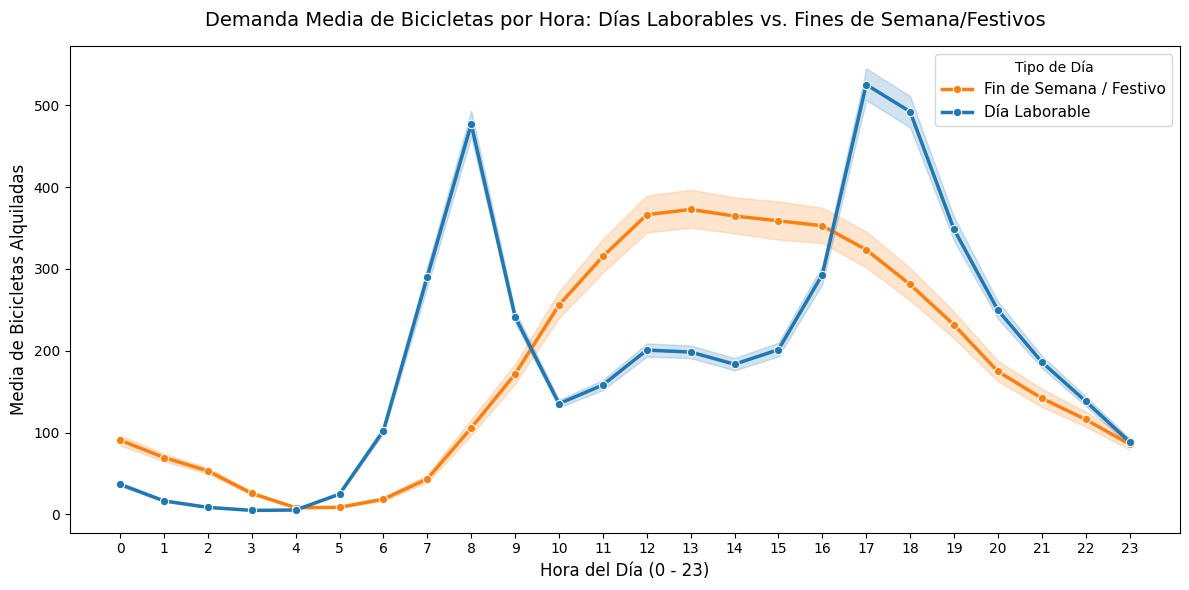

In [13]:
# Análisis comparativo de demanda: días laborables vs. fines de semana
plt.figure(figsize=(12, 6))

# sns.lineplot calcula automáticamente la media de alquileres ('cnt')
# para cada hora ('hr') y separa las líneas según 'workingday'
sns.lineplot(
    data=df,
    x='hr',           # Eje X: las 24 horas
    y='cnt',          # Eje Y: cantidad de bicicletas
    hue='workingday', # Color: diferencia entre laborable y festivo
    palette={1: '#1f77b4', 0: '#ff7f0e'}, # Azul para laborable, Naranja para festivo
    linewidth=2.5,
    marker='o'        # Añade un punto en cada hora para que se vea más claro
)

plt.title('Demanda Media de Bicicletas por Hora: Días Laborables vs. Fines de Semana/Festivos', fontsize=14, pad=15)
plt.xlabel('Hora del Día (0 - 23)', fontsize=12)
plt.ylabel('Media de Bicicletas Alquiladas', fontsize=12)

# Extraemos los elementos gráficos (líneas) y etiquetas originales del gráfico
handles, labels_auto = plt.gca().get_legend_handles_labels()

# Aplicamos los handles extraídos junto con tus etiquetas deseadas
# El orden de las etiquetas debe coincidir con el orden de los handles (0: Fin de semana, 1: Laborable)
plt.legend(
    handles=handles, 
    labels=['Fin de Semana / Festivo', 'Día Laborable'], 
    title='Tipo de Día', 
    fontsize=11
)

# Forzar a que el eje X muestre todas las horas desde la 0 hasta la 23
plt.xticks(range(0, 24))

# Mostrar el gráfico limpio
plt.tight_layout()
plt.show()


Este gráfico revela una diferencia fundamental en el uso del servicio según el día de la semana. Mientras que en los días laborables (línea azul) se observa un patrón claro de "horas punta" asociado a desplazamientos laborales, durante los fines de semana y festivos (línea naranja) la demanda es más uniforme, con un crecimiento gradual que alcanza su máximo al mediodía, lo que sugiere un uso recreativo en lugar de profesional.

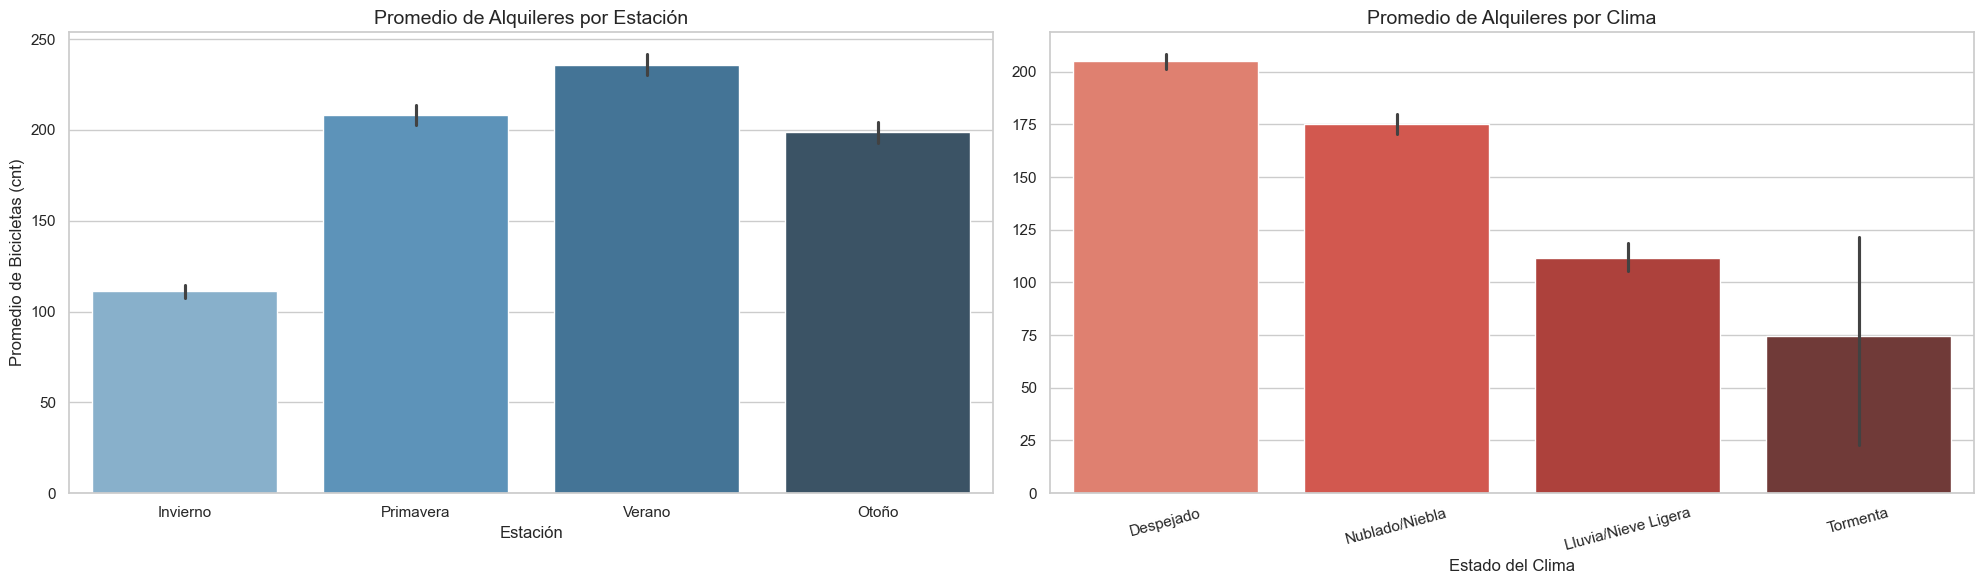

In [14]:
# Análisis del impacto ambiental: Estacionalidad y Condiciones Climáticas
sns.set_theme(style="whitegrid")

# Creamos una figura con 3 subtramas (una al lado de la otra)
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# 1. Gráfico por Estación del Año (season)
# Mapeamos los números a nombres reales para que el gráfico sea profesional
season_labels = {1: 'Invierno', 2: 'Primavera', 3: 'Verano', 4: 'Otoño'}
df_plot = df.copy()
df_plot['season_name'] = df_plot['season'].map(season_labels)

sns.barplot(ax=axes[0], data=df_plot, x='season_name', y='cnt', hue='season_name', palette='Blues_d', legend=False)
axes[0].set_title('Promedio de Alquileres por Estación', fontsize=14)
axes[0].set_xlabel('Estación')
axes[0].set_ylabel('Promedio de Bicicletas (cnt)')

# 2. Gráfico por Estado del Clima (weathersit)
weather_labels = {1: 'Despejado', 2: 'Nublado/Niebla', 3: 'Lluvia/Nieve Ligera', 4: 'Tormenta'}
df_plot['weather_name'] = df_plot['weathersit'].map(weather_labels)

sns.barplot(ax=axes[1], data=df_plot, x='weather_name', y='cnt', hue='weather_name', palette='Reds_d', legend=False)
axes[1].set_title('Promedio de Alquileres por Clima', fontsize=14)
axes[1].set_xlabel('Estado del Clima')
axes[1].set_ylabel('') # Ocultamos el eje Y para que no se repita de forma redundante
axes[1].tick_params(axis='x', rotation=15) # Rotamos un poco el texto si queda apretado

# Ajustamos el espacio entre los gráficos para que no se encimen
plt.tight_layout()

# Mostramos el resultado
plt.show()

El análisis muestra que la demanda de bicicletas depende directamente del clima: el uso es significativamente mayor en estaciones cálidas (verano) y con cielos despejados. Por el contrario, la actividad cae notablemente durante el Invierno o ante condiciones climáticas adversas, como lluvias o tormentas, lo que confirma que el confort térmico es el principal factor que impulsa a los usuarios a elegir este medio de transporte.

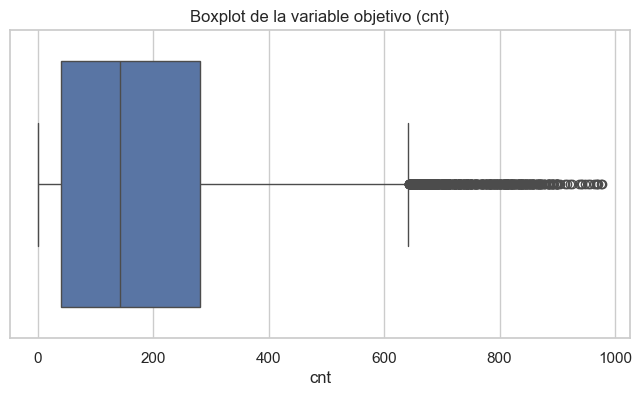

In [15]:
# Distribución y posibles valores atípicos de la variable objetivo
plt.figure(figsize=(8,4))
sns.boxplot(x=df["cnt"])
plt.title("Boxplot de la variable objetivo (cnt)")
plt.show()

El boxplot de la variable cnt revela una distribución con una concentración importante de valores en la parte inferior, indicando que la mayoría de las jornadas presentan una demanda moderada de bicicletas. Se observa una presencia significativa de valores atípicos (outliers) en el extremo superior de la distribución. Estos puntos representan días con una demanda excepcionalmente alta, los cuales, lejos de ser errores, parecen corresponder a jornadas con condiciones climáticas óptimas o eventos especiales, siendo cruciales para entender el potencial máximo de uso del servicio.

## Exportación del dataset procesado

In [16]:
df.to_csv(BASE_DIR / "data" / "bike_clean.csv", index=False)